In [640]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [641]:
df=pd.read_excel("C:\\Users\\srava_kv\\Downloads\\Par_Data for Logistic Regression.xlsx",header=2)
df

,Unnamed: 0,Customer_ID,Status_Checking_Acc,Duration_in_Months,Credit_History,Purposre_Credit_Taken,Credit_Amount,Savings_Acc,Years_At_Present_Employment,Inst_Rt_Income,...,Age,Other_Inst_Plans,Housing,Num_CC,Job,Dependents,Telephone,Foreign_Worker,Default_On_Payment,Count
0,NaN,100001,A11,6,A34,A43,1169,A65,A75,4,...,67,A143,A152,2,A173,1,A192,A201,0,1
1,NaN,100002,A12,48,A32,A43,5951,A61,A73,2,...,22,A143,A152,1,A173,1,A191,A201,0,1
2,NaN,100003,A14,12,A34,A46,2096,A61,A74,2,...,49,A143,A152,1,A172,2,A191,A201,0,1
3,NaN,100004,A11,42,A32,A42,7882,A61,A74,2,...,45,A143,A153,1,A173,2,A191,A201,0,1
4,NaN,100005,A11,24,A33,A40,4870,A61,A73,3,...,53,A143,A153,2,A173,2,A191,A201,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,NaN,104996,A14,12,A32,A42,1736,A61,A74,3,...,31,A143,A152,1,A172,1,A191,A201,0,1
4996,NaN,104997,A11,30,A32,A41,3857,A61,A73,4,...,40,A143,A152,1,A174,1,A192,A201,0,1
4997,NaN,104998,A14,12,A32,A43,804,A61,A75,4,...,38,A143,A152,1,A173,1,A191,A201,0,1
4998,NaN,104999,A11,45,A32,A43,1845,A61,A73,4,...,23,A143,A153,1,A173,1,A192,A201,1,1


In [642]:
df.columns

Index(['Unnamed: 0', 'Customer_ID', 'Status_Checking_Acc',
       'Duration_in_Months', 'Credit_History', 'Purposre_Credit_Taken',
       'Credit_Amount', 'Savings_Acc', 'Years_At_Present_Employment',
       'Inst_Rt_Income', 'Marital_Status_Gender', 'Other_Debtors_Guarantors',
       'Current_Address_Yrs', 'Property', 'Age', 'Other_Inst_Plans ',
       'Housing', 'Num_CC', 'Job', 'Dependents', 'Telephone', 'Foreign_Worker',
       'Default_On_Payment', 'Count'],
      dtype='object')

In [643]:
df.size

120000

In [644]:
df.shape

(5000, 24)

In [645]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   0 non-null      float64
 1   Customer_ID                  5000 non-null   int64  
 2   Status_Checking_Acc          5000 non-null   object 
 3   Duration_in_Months           5000 non-null   int64  
 4   Credit_History               5000 non-null   object 
 5   Purposre_Credit_Taken        5000 non-null   object 
 6   Credit_Amount                5000 non-null   int64  
 7   Savings_Acc                  5000 non-null   object 
 8   Years_At_Present_Employment  5000 non-null   object 
 9   Inst_Rt_Income               5000 non-null   int64  
 10  Marital_Status_Gender        5000 non-null   object 
 11  Other_Debtors_Guarantors     5000 non-null   object 
 12  Current_Address_Yrs          5000 non-null   int64  
 13  Property          

In [646]:
df.drop(["Unnamed: 0","Credit_History","Inst_Rt_Income"],inplace=True,axis=1)

In [647]:
df.drop(["Savings_Acc","Years_At_Present_Employment","Other_Debtors_Guarantors"],inplace=True,axis=1)

In [648]:
df.drop(["Property","Foreign_Worker","Status_Checking_Acc"],inplace=True,axis=1)

In [649]:
df.drop("Housing",inplace=True,axis=1)

In [650]:
df

,Customer_ID,Duration_in_Months,Purposre_Credit_Taken,Credit_Amount,Marital_Status_Gender,Current_Address_Yrs,Age,Other_Inst_Plans,Num_CC,Job,Dependents,Telephone,Default_On_Payment,Count
0,100001,6,A43,1169,A93,4,67,A143,2,A173,1,A192,0,1
1,100002,48,A43,5951,A92,2,22,A143,1,A173,1,A191,0,1
2,100003,12,A46,2096,A93,3,49,A143,1,A172,2,A191,0,1
3,100004,42,A42,7882,A93,4,45,A143,1,A173,2,A191,0,1
4,100005,24,A40,4870,A93,4,53,A143,2,A173,2,A191,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,104996,12,A42,1736,A92,4,31,A143,1,A172,1,A191,0,1
4996,104997,30,A41,3857,A91,4,40,A143,1,A174,1,A192,0,1
4997,104998,12,A43,804,A93,4,38,A143,1,A173,1,A191,0,1
4998,104999,45,A43,1845,A93,4,23,A143,1,A173,1,A192,1,1


In [651]:
df["Purposre_Credit_Taken"].unique()

array(['A43', 'A46', 'A42', 'A40', 'A41', 'A49', 'A44', 'A45', 'A410',
       'A48'], dtype=object)

In [652]:
df["Purposre_Credit_Taken"] = df["Purposre_Credit_Taken"].astype(str).replace({
    "40": "Car",
    "41": "Car",
    "42": "TV",
    "43": "Computer",
    "44": "Bike",
    "45": "House",
    "46": "Personal",
    "48": "Personal",
    "49": "Education",
    "410": "Education"
})

In [653]:
df["Marital_Status_Gender"].unique()

array(['A93', 'A92', 'A91', 'A94'], dtype=object)

In [654]:
result=[]
for i in df["Marital_Status_Gender"]:
    if i=="A91" or i=="A92":
        result.append("Male")
    else:
        result.append("Female")
df["Marital_Status_Gender"]=result

In [655]:
df["Job"].unique()

array(['A173', 'A172', 'A174', 'A171'], dtype=object)

In [656]:
df["Job"] = df["Job"].map({
    "A171": "Unemployed / Unskilled",
    "A172": "Unskilled Worker",
    "A173": "Skilled Employee",
    "A174": "Management / Self-Employed"
})


In [657]:
df["Telephone"].unique()

array(['A192', 'A191'], dtype=object)

In [658]:
df["Telephone"] = df["Telephone"].map({
    "A191": "No",
    "A192": "Yes"
})

In [659]:
df.columns

Index(['Customer_ID', 'Duration_in_Months', 'Purposre_Credit_Taken',
       'Credit_Amount', 'Marital_Status_Gender', 'Current_Address_Yrs', 'Age',
       'Other_Inst_Plans ', 'Num_CC', 'Job', 'Dependents', 'Telephone',
       'Default_On_Payment', 'Count'],
      dtype='object')

In [660]:
df.shape

(5000, 14)

In [661]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Customer_ID            5000 non-null   int64 
 1   Duration_in_Months     5000 non-null   int64 
 2   Purposre_Credit_Taken  5000 non-null   object
 3   Credit_Amount          5000 non-null   int64 
 4   Marital_Status_Gender  5000 non-null   object
 5   Current_Address_Yrs    5000 non-null   int64 
 6   Age                    5000 non-null   int64 
 7   Other_Inst_Plans       5000 non-null   object
 8   Num_CC                 5000 non-null   int64 
 9   Job                    5000 non-null   object
 10  Dependents             5000 non-null   int64 
 11  Telephone              5000 non-null   object
 12  Default_On_Payment     5000 non-null   int64 
 13  Count                  5000 non-null   int64 
dtypes: int64(9), object(5)
memory usage: 547.0+ KB


In [662]:
df["Default_On_Payment"].unique()

array([0, 1])

In [663]:
df["Count"].unique()

array([1])

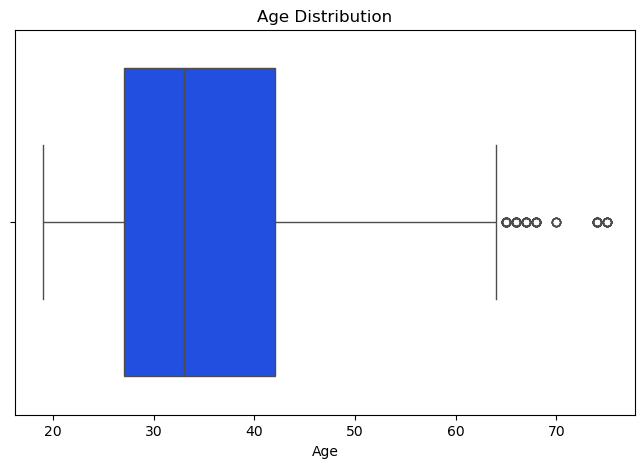

In [664]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Age", data=df,palette="bright")
plt.title("Age Distribution")
plt.show()

In [665]:
df

,Customer_ID,Duration_in_Months,Purposre_Credit_Taken,Credit_Amount,Marital_Status_Gender,Current_Address_Yrs,Age,Other_Inst_Plans,Num_CC,Job,Dependents,Telephone,Default_On_Payment,Count
0,100001,6,A43,1169,Female,4,67,A143,2,Skilled Employee,1,Yes,0,1
1,100002,48,A43,5951,Male,2,22,A143,1,Skilled Employee,1,No,0,1
2,100003,12,A46,2096,Female,3,49,A143,1,Unskilled Worker,2,No,0,1
3,100004,42,A42,7882,Female,4,45,A143,1,Skilled Employee,2,No,0,1
4,100005,24,A40,4870,Female,4,53,A143,2,Skilled Employee,2,No,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,104996,12,A42,1736,Male,4,31,A143,1,Unskilled Worker,1,No,0,1
4996,104997,30,A41,3857,Male,4,40,A143,1,Management / Self-Employed,1,Yes,0,1
4997,104998,12,A43,804,Female,4,38,A143,1,Skilled Employee,1,No,0,1
4998,104999,45,A43,1845,Female,4,23,A143,1,Skilled Employee,1,Yes,1,1


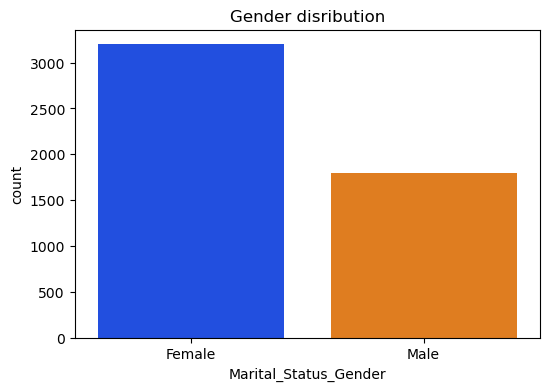

In [666]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Marital_Status_Gender"],data=df,palette="bright")
plt.title("Gender disribution")
plt.show()

In [667]:
df["Marital_Status_Gender"].value_counts(normalize=True) * 100

Marital_Status_Gender
Female    64.0
Male      36.0
Name: proportion, dtype: float64

In [668]:
df["Job"].unique()

array(['Skilled Employee', 'Unskilled Worker',
       'Management / Self-Employed', 'Unemployed / Unskilled'],
      dtype=object)

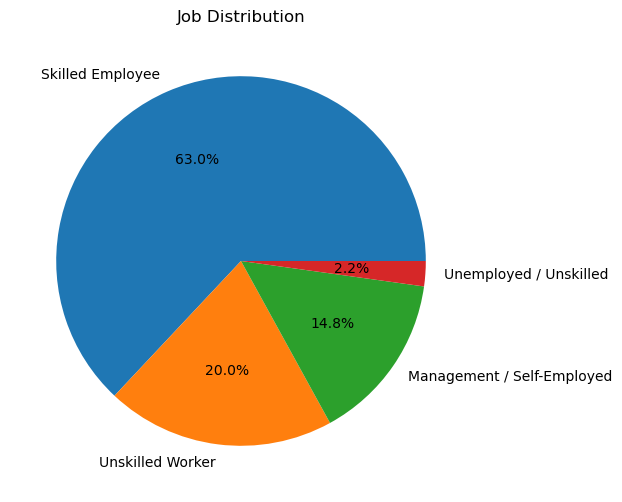

In [669]:
df["Job"].value_counts().plot.pie(
    autopct="%1.1f%%",   
    figsize=(6,6)
)

plt.title("Job Distribution")
plt.ylabel("")  
plt.show()

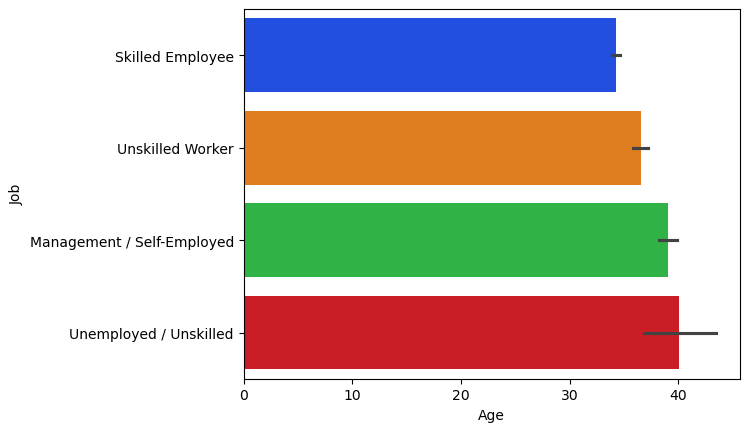

In [670]:
sns.barplot(x=df["Age"],y=df["Job"],data=df,palette="bright")
plt.show()

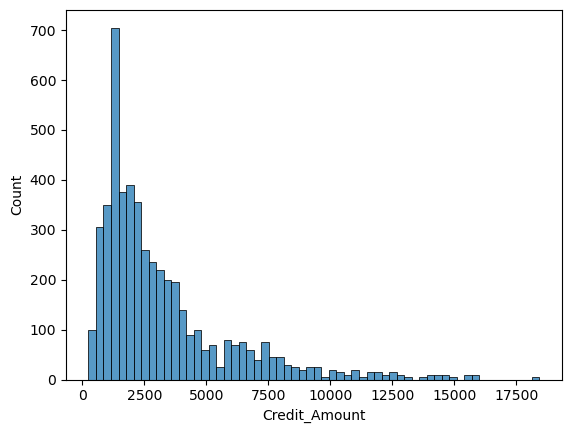

In [671]:
sns.histplot(x=df["Credit_Amount"],data=df,palette="bright")
plt.show()

In [672]:
df

,Customer_ID,Duration_in_Months,Purposre_Credit_Taken,Credit_Amount,Marital_Status_Gender,Current_Address_Yrs,Age,Other_Inst_Plans,Num_CC,Job,Dependents,Telephone,Default_On_Payment,Count
0,100001,6,A43,1169,Female,4,67,A143,2,Skilled Employee,1,Yes,0,1
1,100002,48,A43,5951,Male,2,22,A143,1,Skilled Employee,1,No,0,1
2,100003,12,A46,2096,Female,3,49,A143,1,Unskilled Worker,2,No,0,1
3,100004,42,A42,7882,Female,4,45,A143,1,Skilled Employee,2,No,0,1
4,100005,24,A40,4870,Female,4,53,A143,2,Skilled Employee,2,No,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,104996,12,A42,1736,Male,4,31,A143,1,Unskilled Worker,1,No,0,1
4996,104997,30,A41,3857,Male,4,40,A143,1,Management / Self-Employed,1,Yes,0,1
4997,104998,12,A43,804,Female,4,38,A143,1,Skilled Employee,1,No,0,1
4998,104999,45,A43,1845,Female,4,23,A143,1,Skilled Employee,1,Yes,1,1


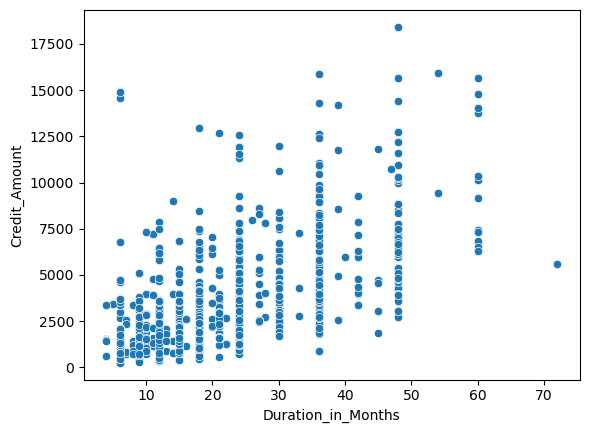

In [673]:
sns.scatterplot(x="Duration_in_Months",y="Credit_Amount",data=df,palette="bright")
plt.show()

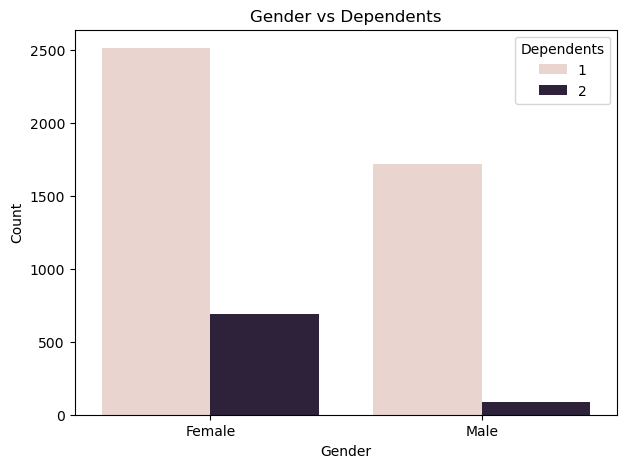

In [674]:
plt.figure(figsize=(7,5))
sns.countplot(x="Marital_Status_Gender", hue="Dependents", data=df)

plt.title("Gender vs Dependents")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

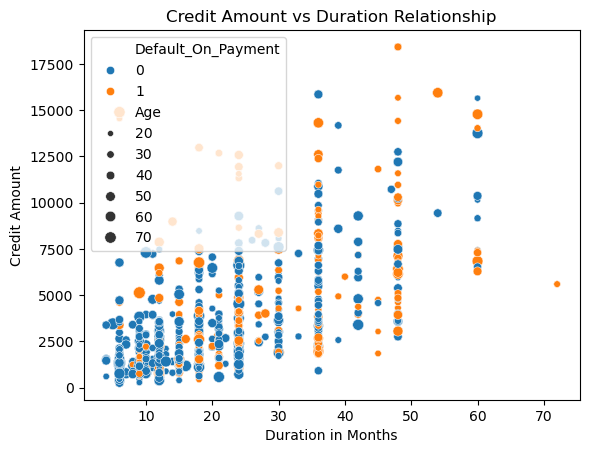

In [675]:
sns.scatterplot(
    x="Duration_in_Months",
    y="Credit_Amount",
    hue="Default_On_Payment",
    size="Age",
    data=df
)

plt.title("Credit Amount vs Duration Relationship")
plt.xlabel("Duration in Months")
plt.ylabel("Credit Amount")
plt.show()

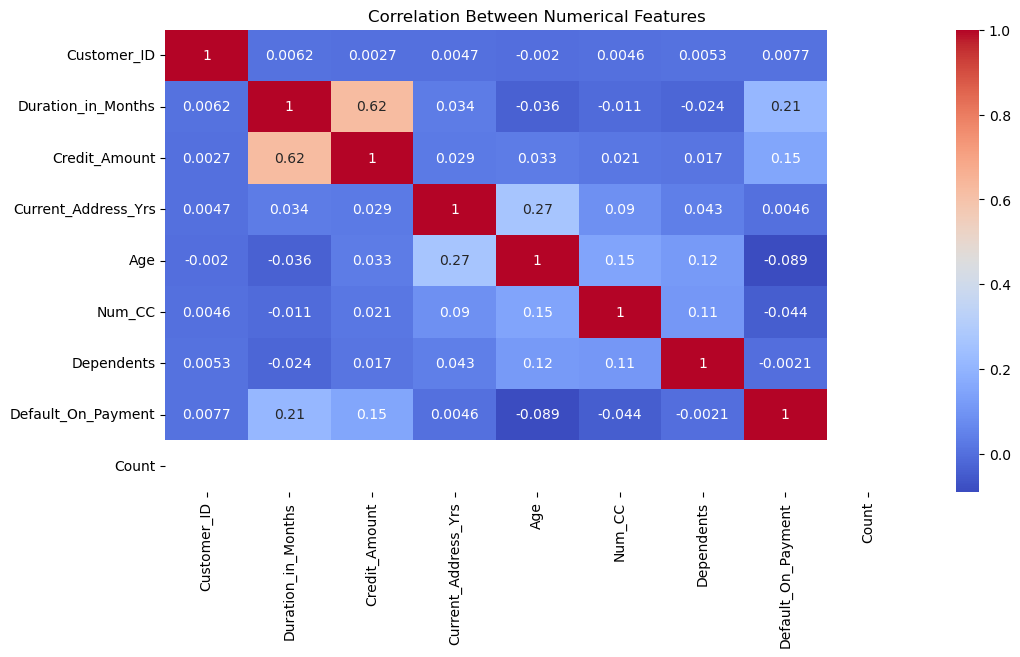

In [677]:
plt.figure(figsize=(12,6))

num_cols = df.select_dtypes(include=["int64","float64"]).columns

sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Between Numerical Features")
plt.show()

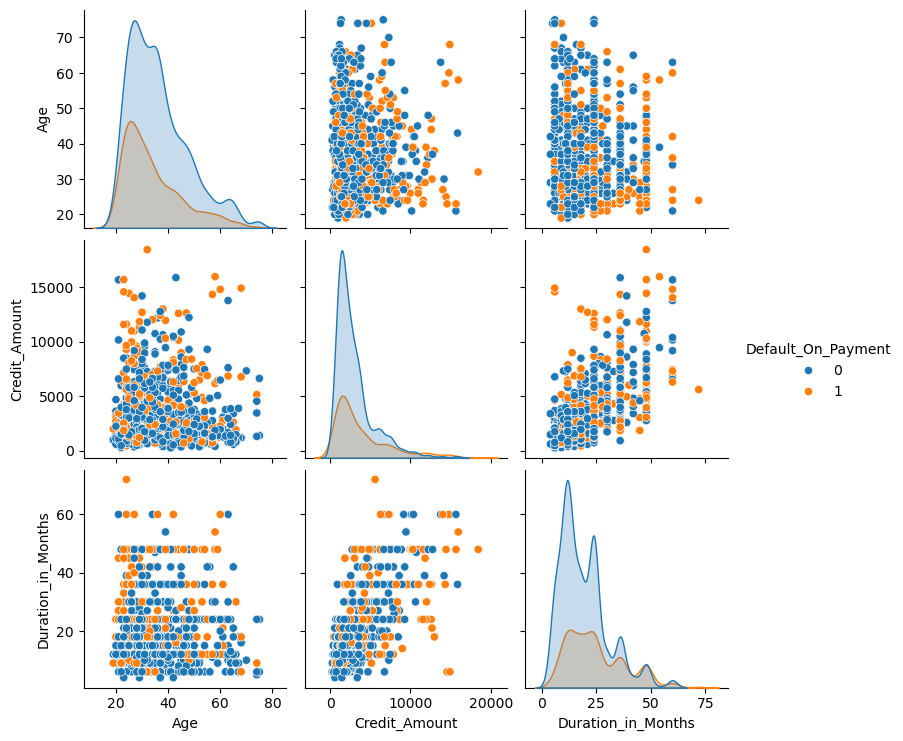

In [679]:
sns.pairplot(
    df[["Age","Credit_Amount","Duration_in_Months","Default_On_Payment"]],
    hue="Default_On_Payment"
)

plt.show()

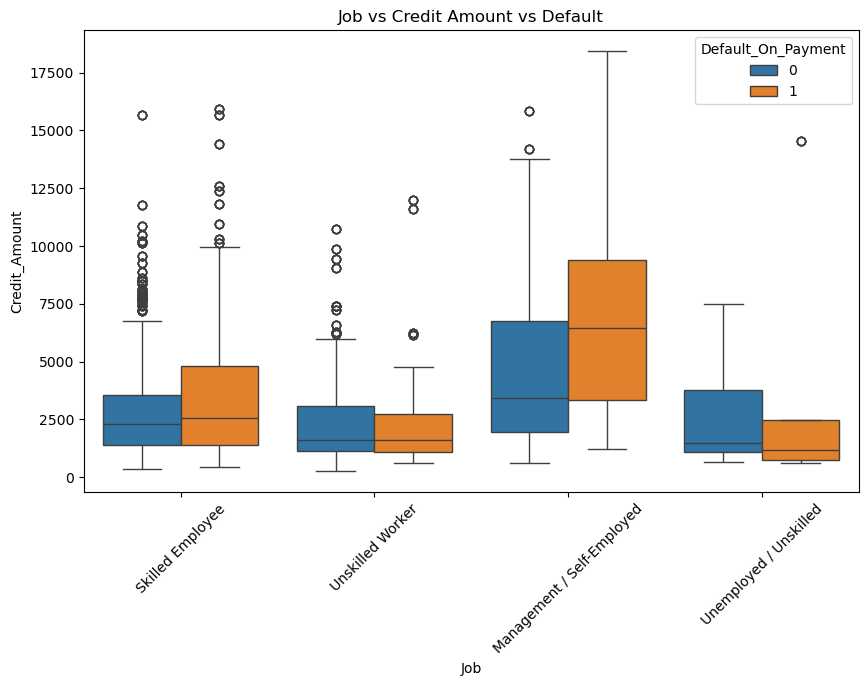

In [680]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Job",
    y="Credit_Amount",
    hue="Default_On_Payment",
    data=df
)

plt.title("Job vs Credit Amount vs Default")
plt.xticks(rotation=45)
plt.show()